<a href="https://colab.research.google.com/github/geopayme/AstroPhysics/blob/main/CPS1_FEniCSx_Digital_Coupon_Simulation_Colab_v4_NET_AWARE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CPS-1 Digital Coupon Simulation — FEniCSx / Google Colab

This notebook models a **CPS-1 eight-state programmable glass-core interposer coupon** using FEniCSx for the PDE portions.

The first concept gate is:

> If the eight states cannot coexist, switch, isolate, conduct, and survive basic processing, the concept fails early.  
> If the coupon works, the result justifies finer routing, multilayer integration, through-glass-via experiments, and reliability work.

## CPS-1 state alphabet

| State | Meaning |
|---:|---|
| 0 | inert/passive |
| 1 | etch-open |
| 2 | metal-growth seed |
| 3 | growth inhibitor |
| 4 | graphitic/conductive path |
| 5 | dielectric/passivation |
| 6 | sacrificial/removable |
| 7 | repairable/reversible |

## What this notebook simulates

1. Digital coupon geometry.
2. State transition/coexistence logic.
3. FEniCSx transient diffusion for switching/proton/ion blur.
4. FEniCSx transient diffusion for inhibitor spread.
5. Simplified plating-growth confinement.
6. Conductivity map.
7. Pad-to-pad continuity.
8. Isolation comb leakage.
9. LCO non-compensatory pass/fail gate.

## How to run

In Colab, use **Runtime → Run all** after the FEniCSx install cell finishes. This v3 notebook also includes self-healing checks before dependent simulation cells, so `sigma0` is rebuilt if the runtime was reset or if the coupon cell was skipped.

## 0. Install FEniCSx on Google Colab

This uses the **FEM on Colab** install script for FEniCSx.  
Run this first. It may take several minutes.

### FEniCSx compatibility note

This version includes the required `petsc_options_prefix` argument in `LinearProblem`. Without it, newer FEniCSx builds can raise: `TypeError: LinearProblem.__init__() missing 1 required keyword-only argument: 'petsc_options_prefix'`.

In [ ]:
try:
    import dolfinx
    print("FEniCSx already installed.")
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh" -O "/tmp/fenicsx-install.sh" && bash "/tmp/fenicsx-install.sh"
    import dolfinx
    print("FEniCSx installed.")

--2026-06-28 02:17:47--  https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4339 (4.2K) [application/x-sh]
Saving to: ‘/tmp/fenicsx-install.sh’

/tmp/fenicsx-instal 100%[===================>]   4.24K  --.-KB/s    in 0s      

2026-06-28 02:17:47 (41.7 MB/s) - ‘/tmp/fenicsx-install.sh’ saved [4339/4339]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICSX_INSTALLED=/usr/local/share/fem-on-colab/fenicsx.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenicsx.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/2cc1288d/release

## 1. Imports and configuration

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.interpolate import griddata

from mpi4py import MPI
import ufl
from dolfinx import mesh, fem
from dolfinx.fem.petsc import LinearProblem

np.random.seed(7)

# Coupon grid used for state logic and electrical network.
NX, NY = 220, 140
LX_UM, LY_UM = 220.0, 140.0

STATE = {
    0: "inert/passive",
    1: "etch-open",
    2: "metal-growth seed",
    3: "growth inhibitor",
    4: "graphitic/conductive path",
    5: "dielectric/passivation",
    6: "sacrificial/removable",
    7: "repairable/reversible"
}

STATE_SHORT = {
    0: "inert",
    1: "etch",
    2: "seed",
    3: "inhib",
    4: "graph",
    5: "diel",
    6: "sacr",
    7: "repair"
}

state_colors = [
    "#d9d9d9", "#ffb347", "#1f77b4", "#d62728",
    "#2ca02c", "#9467bd", "#8c564b", "#17becf"
]
cmap_states = ListedColormap(state_colors)
norm_states = BoundaryNorm(np.arange(-0.5, 8.5, 1), cmap_states.N)

print("dolfinx version:", dolfinx.__version__)

dolfinx version: 0.11.0.post0


## 2. Build the CPS-1 digital coupon

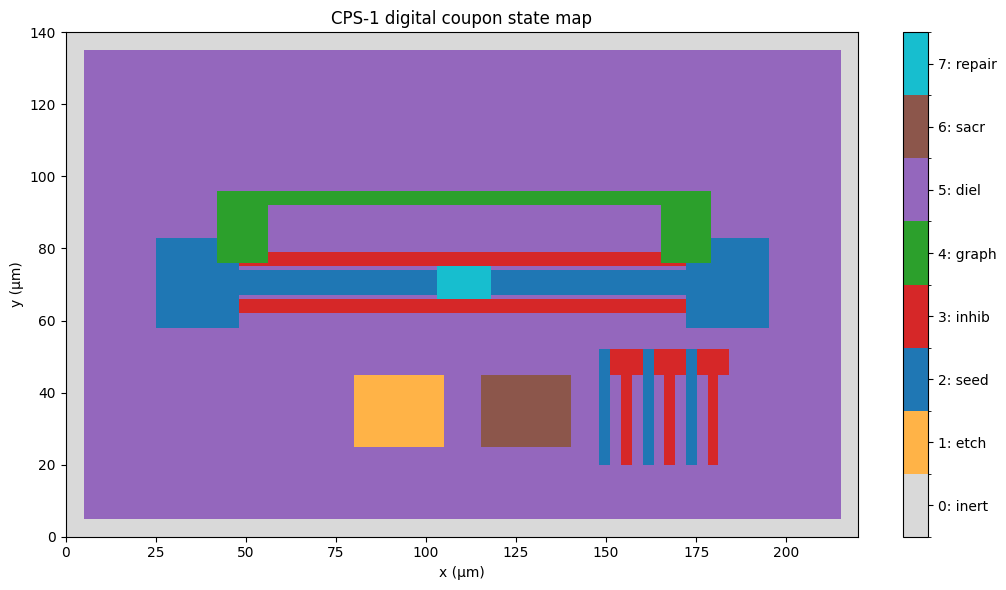

In [ ]:
def rect(mask, x0, x1, y0, y1, value):
    mask[y0:y1, x0:x1] = value

def build_coupon(nx=NX, ny=NY):
    sigma = np.zeros((ny, nx), dtype=np.int8)

    # Background dielectric/passivation.
    sigma[:, :] = 5

    # Inert border.
    sigma[:5, :] = 0
    sigma[-5:, :] = 0
    sigma[:, :5] = 0
    sigma[:, -5:] = 0

    # Two pad fields as metal-growth seed regions.
    rect(sigma, 25, 48, 58, 83, 2)
    rect(sigma, 172, 195, 58, 83, 2)

    # Main seed route corridor.
    rect(sigma, 48, 172, 67, 74, 2)

    # Inhibitor boundary around route.
    rect(sigma, 48, 172, 62, 66, 3)
    rect(sigma, 48, 172, 75, 79, 3)

    # Graphitic backup route.
    rect(sigma, 55, 165, 92, 96, 4)
    rect(sigma, 42, 56, 76, 96, 4)
    rect(sigma, 165, 179, 76, 96, 4)

    # Etch-open test window.
    rect(sigma, 80, 105, 25, 45, 1)

    # Sacrificial/removable bridge test.
    rect(sigma, 115, 140, 25, 45, 6)

    # Repairable/reversible patch on main route.
    rect(sigma, 103, 118, 66, 75, 7)

    # Isolation comb structures.
    for k in range(6):
        rect(sigma, 148 + 6*k, 151 + 6*k, 20, 52, 2 if k % 2 == 0 else 3)
        rect(sigma, 151 + 6*k, 154 + 6*k, 45, 52, 3)

    return sigma

sigma0 = build_coupon()

def plot_state_map(sigma, title="CPS-1 digital coupon state map"):
    plt.figure(figsize=(12, 6))
    im = plt.imshow(sigma, origin="lower", cmap=cmap_states, norm=norm_states,
                    extent=[0, LX_UM, 0, LY_UM], aspect="equal")
    cbar = plt.colorbar(im, ticks=np.arange(8), fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels([f"{k}: {STATE_SHORT[k]}" for k in range(8)])
    plt.title(title)
    plt.xlabel("x (µm)")
    plt.ylabel("y (µm)")
    plt.tight_layout()
    plt.show()

plot_state_map(sigma0)

## 3. State transition, coexistence, and survival gates

These matrices are placeholders for a first digital gate.

- \(T_{ij}\): state \(i\) can transition to state \(j\).
- \(C_{ij}\): state \(i\) can coexist next to state \(j\).
- \(S_{ip}\): state \(i\) survives process step \(p\).

Number of net-aware incompatible adjacent pairs: 0
First 10: []


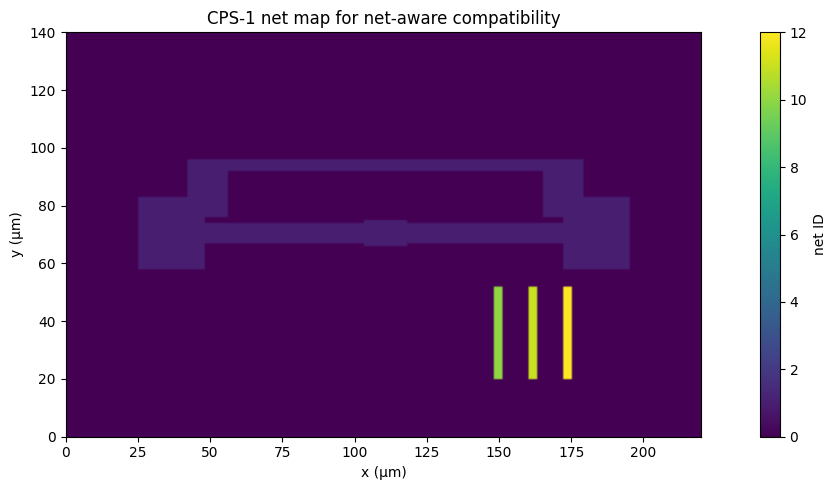

In [ ]:

T = np.zeros((8, 8), dtype=bool)
for i in range(8):
    T[i, i] = True

allowed_transitions = [
    (0,1), (0,2), (0,3), (0,5), (0,6), (0,7),
    (1,0), (1,5),
    (2,5), (2,7),
    (3,0), (3,5), (3,7),
    (4,5), (4,7),
    (6,0), (6,5),
    (7,2), (7,3), (7,4), (7,5)
]
for i, j in allowed_transitions:
    T[i, j] = True

# Base coexistence matrix.
# Important: C is only a materials-level screen.
# Electrical net identity is handled separately below.
C = np.ones((8,8), dtype=bool)

# Conservative incompatibilities that are genuinely materials/process risks.
incompatible_pairs = [
    (1,2),  # etch-open near seed may undercut.
    (1,4),  # etch-open near graphitic path may undercut.
    (6,2),  # sacrificial near seed may contaminate plating unless isolated.
]
for i, j in incompatible_pairs:
    C[i, j] = False
    C[j, i] = False

# Designed useful coexistence.
C[2,3] = C[3,2] = True
C[4,5] = C[5,4] = True
C[1,5] = C[5,1] = True
C[6,5] = C[5,6] = True
C[7,2] = C[2,7] = True
C[7,3] = C[3,7] = True
C[7,4] = C[4,7] = True
C[7,5] = C[5,7] = True

process_steps = [
    "clean",
    "bake",
    "activation",
    "laser_graphitization",
    "wet_develop",
    "etch",
    "plating",
    "strip_sacrificial",
    "passivation_cure",
    "thermal_cycle"
]

S = np.ones((8, len(process_steps)), dtype=bool)

def fail(state, step_name):
    S[state, process_steps.index(step_name)] = False

fail(6, "strip_sacrificial")
fail(7, "passivation_cure")
fail(3, "etch")
fail(4, "wet_develop")

def build_net_map(sigma):
    """
    Net-aware compatibility map.

    - net 1: main pad-to-pad route, repair region, and graphitic backup route.
    - net 10+: isolated comb seed fingers.
    - net 0: non-conductive / no assigned electrical net.

    This prevents the checker from declaring same-net seed continuity invalid.
    Different-net conductive adjacency remains a short risk.
    """
    net = np.zeros_like(sigma, dtype=np.int16)

    # Main route + pads + repair patch.
    net[58:83, 25:48] = 1
    net[58:83, 172:195] = 1
    net[67:74, 48:172] = 1
    net[66:75, 103:118] = 1

    # Graphitic backup route is intentionally same net as main route in this coupon.
    net[92:96, 55:165] = 1
    net[76:96, 42:56] = 1
    net[76:96, 165:179] = 1

    # Comb seed fingers: separate assigned nets.
    comb_id = 10
    for k in range(6):
        x0 = 148 + 6*k
        if k % 2 == 0:
            net[20:52, x0:x0+3] = comb_id
            comb_id += 1

    return net

net_map = build_net_map(sigma0)

def is_conductive_state(s):
    return s in (2, 4, 7)

def check_adjacent_coexistence_net_aware(sigma, C, net_map):
    """
    Net-aware state compatibility.

    Materials-level incompatible adjacencies are still flagged.

    Conductive-to-conductive adjacency is allowed only when:
    - both regions belong to the same nonzero electrical net.

    This fixes the false FAIL caused by treating seed-to-seed continuity
    inside the same route/pad as a state-compatibility violation.
    """
    bad = []
    ny, nx = sigma.shape

    for dy, dx in [(0,1), (1,0)]:
        for y in range(ny - dy):
            for x in range(nx - dx):
                a = int(sigma[y, x])
                b = int(sigma[y + dy, x + dx])
                na = int(net_map[y, x])
                nb = int(net_map[y + dy, x + dx])

                # Same-net conductive continuity is intentional.
                if is_conductive_state(a) and is_conductive_state(b):
                    if na != 0 and na == nb:
                        continue
                    # Different conductive nets touching is a short risk.
                    if na != nb:
                        bad.append((int(x), int(y), a, b, na, nb, "different conductive nets touching"))
                        continue

                # Materials-level screen.
                if not C[a, b]:
                    bad.append((int(x), int(y), a, b, na, nb, "materials adjacency"))
                    continue

    return bad

bad_pairs = check_adjacent_coexistence_net_aware(sigma0, C, net_map)

print("Number of net-aware incompatible adjacent pairs:", len(bad_pairs))
print("First 10:", bad_pairs[:10])

plt.figure(figsize=(12, 5))
plt.imshow(net_map, origin="lower", extent=[0, LX_UM, 0, LY_UM], aspect="equal")
plt.colorbar(label="net ID")
plt.title("CPS-1 net map for net-aware compatibility")
plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.tight_layout()
plt.show()


## 4. FEniCSx PDE helper functions

We solve a transient diffusion equation:

\[
\frac{c^{n+1}-c^n}{\Delta t} - D \nabla^2 c^{n+1} = R(x,y)
\]

Natural no-flux boundary conditions are used.

This models switching blur for proton/ion/chemical activation and inhibitor spread.

In [ ]:
def create_fenicsx_domain(nx_cells=110, ny_cells=70):
    domain = mesh.create_rectangle(
        MPI.COMM_WORLD,
        [np.array([0.0, 0.0]), np.array([LX_UM, LY_UM])],
        [nx_cells, ny_cells],
        cell_type=mesh.CellType.triangle
    )
    return domain

def mask_to_callable(mask):
    ny, nx = mask.shape
    def f(x):
        ix = np.clip((x[0] / LX_UM * (nx - 1)).astype(int), 0, nx - 1)
        iy = np.clip((x[1] / LY_UM * (ny - 1)).astype(int), 0, ny - 1)
        return mask[iy, ix].astype(np.float64)
    return f

def function_to_regular_grid(u, V, nx=NX, ny=NY):
    coords = V.tabulate_dof_coordinates()[:, :2]
    values = u.x.array.real.copy()

    gx = np.linspace(0, LX_UM, nx)
    gy = np.linspace(0, LY_UM, ny)
    Xg, Yg = np.meshgrid(gx, gy)

    grid = griddata(coords, values, (Xg, Yg), method="linear", fill_value=0.0)
    return grid

def run_fenicsx_diffusion(source_mask, D_value=0.35, source_strength=1.0, dt=0.03, nsteps=80,
                          nx_cells=110, ny_cells=70):
    domain = create_fenicsx_domain(nx_cells, ny_cells)
    V = fem.functionspace(domain, ("Lagrange", 1))

    c_n = fem.Function(V)
    source = fem.Function(V)
    source.interpolate(mask_to_callable(source_mask))

    D = fem.Constant(domain, D_value)
    dt_c = fem.Constant(domain, dt)
    source_strength_c = fem.Constant(domain, source_strength)

    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)

    a = (u * v + dt_c * D * ufl.dot(ufl.grad(u), ufl.grad(v))) * ufl.dx
    L = (c_n * v + dt_c * source_strength_c * source * v) * ufl.dx

    problem = LinearProblem(
        a,
        L,
        bcs=[],
        petsc_options_prefix="cps1_diffusion_",
        petsc_options={
            "ksp_type": "cg",
            "pc_type": "hypre"
        }
    )

    c = None
    for _ in range(nsteps):
        c = problem.solve()
        c_n.x.array[:] = c.x.array

    return function_to_regular_grid(c, V, nx=NX, ny=NY)

## 5. FEniCSx switching-blur simulation

The activation source is the seed/repair region.  
The output metric is how much activation leaks outside the intended area.

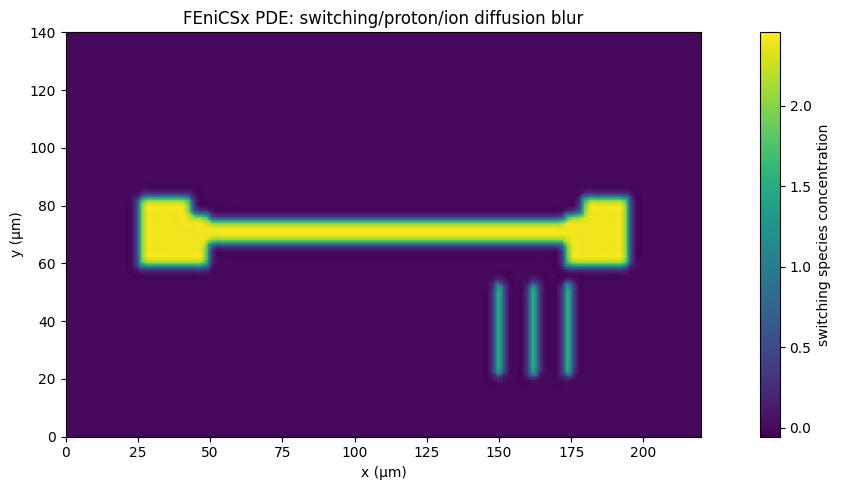

Leak fraction above 25% of max outside intended region: 0.0152


In [ ]:

# --- Self-healing CPS-1 coupon bootstrap ---
# This prevents "NameError: sigma0 is not defined" if Colab runtime was reset
# or if the coupon-construction cell was skipped.

if "NX" not in globals():
    NX, NY = 220, 140
    LX_UM, LY_UM = 220.0, 140.0

if "rect" not in globals():
    def rect(mask, x0, x1, y0, y1, value):
        mask[y0:y1, x0:x1] = value

if "build_coupon" not in globals():
    def build_coupon(nx=NX, ny=NY):
        import numpy as np
        sigma = np.zeros((ny, nx), dtype=np.int8)

        # Background dielectric/passivation.
        sigma[:, :] = 5

        # Inert border.
        sigma[:5, :] = 0
        sigma[-5:, :] = 0
        sigma[:, :5] = 0
        sigma[:, -5:] = 0

        # Two pad fields as metal-growth seed regions.
        rect(sigma, 25, 48, 58, 83, 2)
        rect(sigma, 172, 195, 58, 83, 2)

        # Main seed route corridor.
        rect(sigma, 48, 172, 67, 74, 2)

        # Inhibitor boundary around route.
        rect(sigma, 48, 172, 62, 66, 3)
        rect(sigma, 48, 172, 75, 79, 3)

        # Graphitic backup route.
        rect(sigma, 55, 165, 92, 96, 4)
        rect(sigma, 42, 56, 76, 96, 4)
        rect(sigma, 165, 179, 76, 96, 4)

        # Etch-open test window.
        rect(sigma, 80, 105, 25, 45, 1)

        # Sacrificial/removable bridge test.
        rect(sigma, 115, 140, 25, 45, 6)

        # Repairable/reversible patch on main route.
        rect(sigma, 103, 118, 66, 75, 7)

        # Isolation comb structures.
        for k in range(6):
            rect(sigma, 148 + 6*k, 151 + 6*k, 20, 52, 2 if k % 2 == 0 else 3)
            rect(sigma, 151 + 6*k, 154 + 6*k, 45, 52, 3)

        return sigma

if "sigma0" not in globals():
    sigma0 = build_coupon()
    print("sigma0 was missing; rebuilt CPS-1 coupon state map.")

if "net_map" not in globals() and "build_net_map" in globals():
    net_map = build_net_map(sigma0)
    print("net_map was missing; rebuilt net map.")

if "bad_pairs" not in globals() and "check_adjacent_coexistence_net_aware" in globals() and "C" in globals() and "net_map" in globals():
    bad_pairs = check_adjacent_coexistence_net_aware(sigma0, C, net_map)
    print("bad_pairs was missing; rebuilt net-aware adjacency check.")



activation_mask = (sigma0 == 2) | (sigma0 == 7)

c_switch = run_fenicsx_diffusion(
    activation_mask,
    D_value=0.35,
    source_strength=1.0,
    dt=0.03,
    nsteps=80,
    nx_cells=110,
    ny_cells=70
)

plt.figure(figsize=(12, 5))
plt.imshow(c_switch, origin="lower", extent=[0, LX_UM, 0, LY_UM], aspect="equal")
plt.colorbar(label="switching species concentration")
plt.title("FEniCSx PDE: switching/proton/ion diffusion blur")
plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.tight_layout()
plt.show()

leak_region = ~activation_mask
leak_fraction = (c_switch[leak_region] > 0.25 * c_switch.max()).mean()
print(f"Leak fraction above 25% of max outside intended region: {leak_fraction:.4f}")

## 6. FEniCSx inhibitor-field diffusion and simplified plating growth

The inhibitor field originates from state 3.  
Metal grows mostly where state 2 or resolved state 7 permits growth, and is suppressed near inhibitor-rich regions.

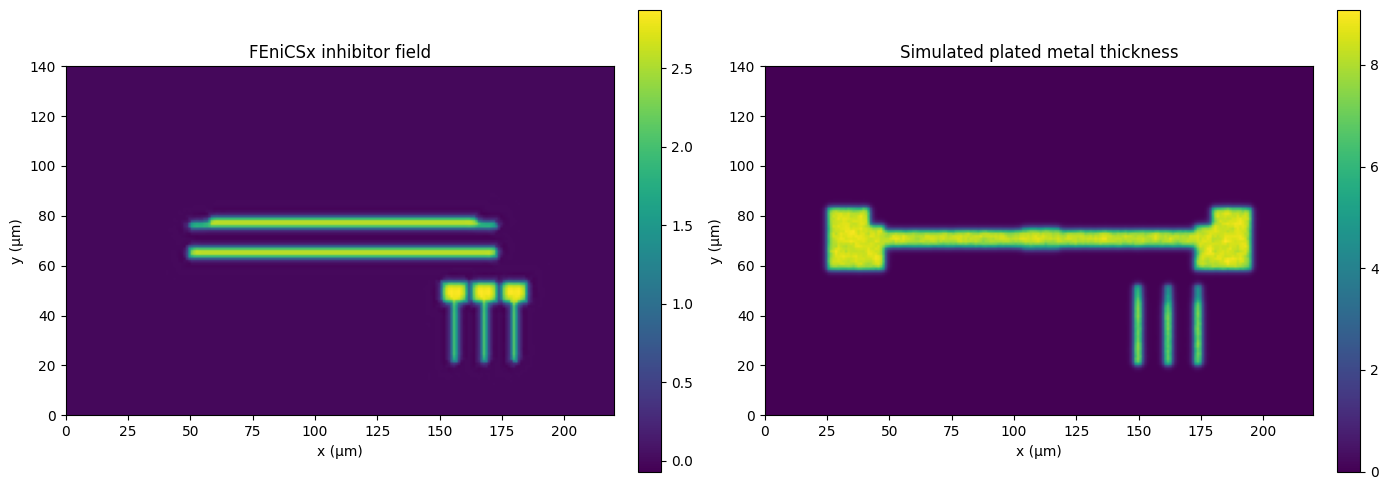

Stray metal growth fraction: 0.00435


In [ ]:

# --- Self-healing CPS-1 coupon bootstrap ---
# This prevents "NameError: sigma0 is not defined" if Colab runtime was reset
# or if the coupon-construction cell was skipped.

if "NX" not in globals():
    NX, NY = 220, 140
    LX_UM, LY_UM = 220.0, 140.0

if "rect" not in globals():
    def rect(mask, x0, x1, y0, y1, value):
        mask[y0:y1, x0:x1] = value

if "build_coupon" not in globals():
    def build_coupon(nx=NX, ny=NY):
        import numpy as np
        sigma = np.zeros((ny, nx), dtype=np.int8)

        # Background dielectric/passivation.
        sigma[:, :] = 5

        # Inert border.
        sigma[:5, :] = 0
        sigma[-5:, :] = 0
        sigma[:, :5] = 0
        sigma[:, -5:] = 0

        # Two pad fields as metal-growth seed regions.
        rect(sigma, 25, 48, 58, 83, 2)
        rect(sigma, 172, 195, 58, 83, 2)

        # Main seed route corridor.
        rect(sigma, 48, 172, 67, 74, 2)

        # Inhibitor boundary around route.
        rect(sigma, 48, 172, 62, 66, 3)
        rect(sigma, 48, 172, 75, 79, 3)

        # Graphitic backup route.
        rect(sigma, 55, 165, 92, 96, 4)
        rect(sigma, 42, 56, 76, 96, 4)
        rect(sigma, 165, 179, 76, 96, 4)

        # Etch-open test window.
        rect(sigma, 80, 105, 25, 45, 1)

        # Sacrificial/removable bridge test.
        rect(sigma, 115, 140, 25, 45, 6)

        # Repairable/reversible patch on main route.
        rect(sigma, 103, 118, 66, 75, 7)

        # Isolation comb structures.
        for k in range(6):
            rect(sigma, 148 + 6*k, 151 + 6*k, 20, 52, 2 if k % 2 == 0 else 3)
            rect(sigma, 151 + 6*k, 154 + 6*k, 45, 52, 3)

        return sigma

if "sigma0" not in globals():
    sigma0 = build_coupon()
    print("sigma0 was missing; rebuilt CPS-1 coupon state map.")

if "net_map" not in globals() and "build_net_map" in globals():
    net_map = build_net_map(sigma0)
    print("net_map was missing; rebuilt net map.")

if "bad_pairs" not in globals() and "check_adjacent_coexistence_net_aware" in globals() and "C" in globals() and "net_map" in globals():
    bad_pairs = check_adjacent_coexistence_net_aware(sigma0, C, net_map)
    print("bad_pairs was missing; rebuilt net-aware adjacency check.")



inhibitor_mask = (sigma0 == 3)

inhib = run_fenicsx_diffusion(
    inhibitor_mask,
    D_value=0.18,
    source_strength=1.0,
    dt=0.04,
    nsteps=70,
    nx_cells=110,
    ny_cells=70
)

def simulate_plating_growth(sigma, inhibitor_field, growth_rate=0.10, steps=85, repair_to_seed=True):
    seed = (sigma == 2)
    if repair_to_seed:
        seed = seed | (sigma == 7)

    inhib_norm = inhibitor_field / (inhibitor_field.max() + 1e-12)
    suppression = np.clip(inhib_norm, 0, 1)

    roughness = np.random.normal(loc=1.0, scale=0.08, size=sigma.shape)
    roughness = np.clip(roughness, 0.7, 1.3)

    h = np.zeros_like(inhibitor_field)
    for _ in range(steps):
        dh = growth_rate * seed.astype(float) * (1.0 - 0.85 * suppression) * roughness
        dh = np.maximum(dh, 0)
        h += dh

        h_pad = np.pad(h, 1, mode="edge")
        lap = h_pad[1:-1, :-2] + h_pad[1:-1, 2:] + h_pad[:-2, 1:-1] + h_pad[2:, 1:-1] - 4*h
        h += 0.015 * lap
        h = np.maximum(h, 0)

    return h

h_metal = simulate_plating_growth(sigma0, inhib, growth_rate=0.10, steps=85, repair_to_seed=True)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
im0 = ax[0].imshow(inhib, origin="lower", extent=[0, LX_UM, 0, LY_UM], aspect="equal")
ax[0].set_title("FEniCSx inhibitor field")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(h_metal, origin="lower", extent=[0, LX_UM, 0, LY_UM], aspect="equal")
ax[1].set_title("Simulated plated metal thickness")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

for a in ax:
    a.set_xlabel("x (µm)")
    a.set_ylabel("y (µm)")
plt.tight_layout()
plt.show()

valid_growth_region = (sigma0 == 2) | (sigma0 == 7)
stray_growth = (h_metal > 0.25 * h_metal.max()) & (~valid_growth_region)
stray_fraction = stray_growth.mean()
print(f"Stray metal growth fraction: {stray_fraction:.5f}")

## 7. Electrical continuity and isolation network

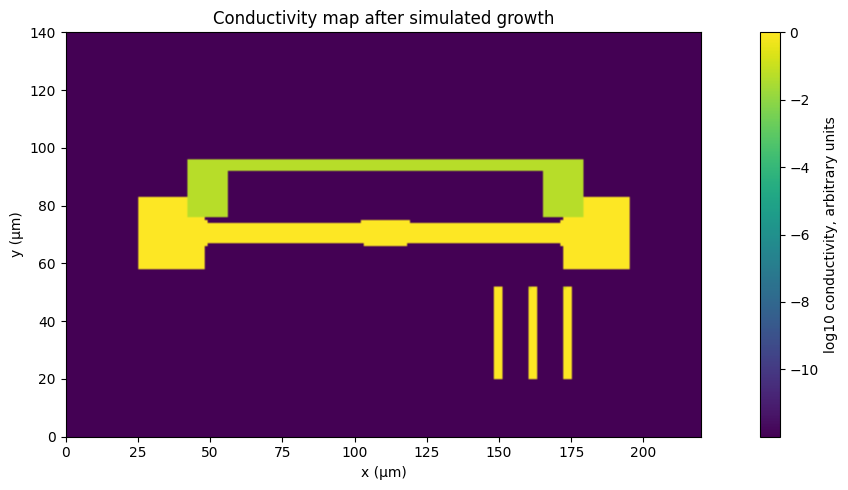

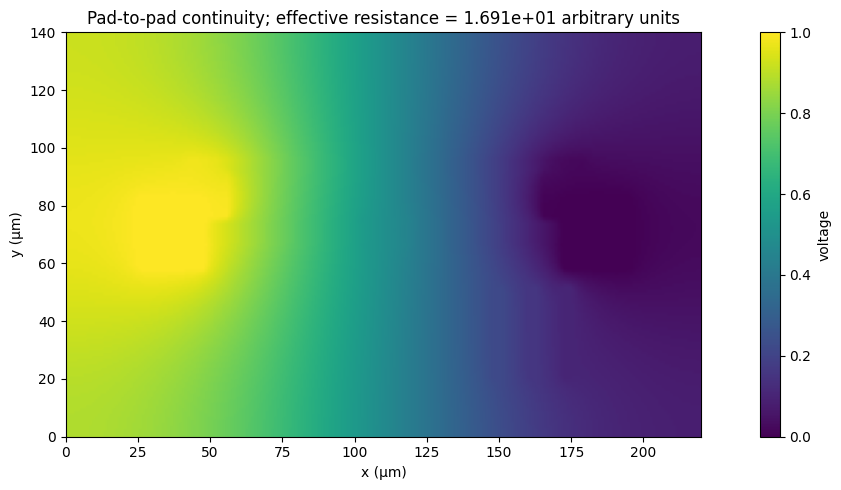

Estimated pad-to-pad current: 0.059135564192466614
Estimated effective resistance: 16.91029778197993


In [ ]:

# --- Self-healing CPS-1 coupon bootstrap ---
# This prevents "NameError: sigma0 is not defined" if Colab runtime was reset
# or if the coupon-construction cell was skipped.

if "NX" not in globals():
    NX, NY = 220, 140
    LX_UM, LY_UM = 220.0, 140.0

if "rect" not in globals():
    def rect(mask, x0, x1, y0, y1, value):
        mask[y0:y1, x0:x1] = value

if "build_coupon" not in globals():
    def build_coupon(nx=NX, ny=NY):
        import numpy as np
        sigma = np.zeros((ny, nx), dtype=np.int8)

        # Background dielectric/passivation.
        sigma[:, :] = 5

        # Inert border.
        sigma[:5, :] = 0
        sigma[-5:, :] = 0
        sigma[:, :5] = 0
        sigma[:, -5:] = 0

        # Two pad fields as metal-growth seed regions.
        rect(sigma, 25, 48, 58, 83, 2)
        rect(sigma, 172, 195, 58, 83, 2)

        # Main seed route corridor.
        rect(sigma, 48, 172, 67, 74, 2)

        # Inhibitor boundary around route.
        rect(sigma, 48, 172, 62, 66, 3)
        rect(sigma, 48, 172, 75, 79, 3)

        # Graphitic backup route.
        rect(sigma, 55, 165, 92, 96, 4)
        rect(sigma, 42, 56, 76, 96, 4)
        rect(sigma, 165, 179, 76, 96, 4)

        # Etch-open test window.
        rect(sigma, 80, 105, 25, 45, 1)

        # Sacrificial/removable bridge test.
        rect(sigma, 115, 140, 25, 45, 6)

        # Repairable/reversible patch on main route.
        rect(sigma, 103, 118, 66, 75, 7)

        # Isolation comb structures.
        for k in range(6):
            rect(sigma, 148 + 6*k, 151 + 6*k, 20, 52, 2 if k % 2 == 0 else 3)
            rect(sigma, 151 + 6*k, 154 + 6*k, 45, 52, 3)

        return sigma

if "sigma0" not in globals():
    sigma0 = build_coupon()
    print("sigma0 was missing; rebuilt CPS-1 coupon state map.")

if "net_map" not in globals() and "build_net_map" in globals():
    net_map = build_net_map(sigma0)
    print("net_map was missing; rebuilt net map.")

if "bad_pairs" not in globals() and "check_adjacent_coexistence_net_aware" in globals() and "C" in globals() and "net_map" in globals():
    bad_pairs = check_adjacent_coexistence_net_aware(sigma0, C, net_map)
    print("bad_pairs was missing; rebuilt net-aware adjacency check.")



def build_conductivity_map(sigma, h_metal, metal_threshold=0.30):
    h_norm = h_metal / (h_metal.max() + 1e-12)
    metal = h_norm > metal_threshold

    cond = np.full(sigma.shape, 1e-12, dtype=float)
    cond[metal] = 1.0
    cond[sigma == 4] = 0.05
    cond[sigma == 2] = np.maximum(cond[sigma == 2], 0.2)
    cond[sigma == 7] = np.maximum(cond[sigma == 7], 0.1)
    return cond

cond = build_conductivity_map(sigma0, h_metal, metal_threshold=0.30)

plt.figure(figsize=(12, 5))
plt.imshow(np.log10(cond + 1e-15), origin="lower", extent=[0, LX_UM, 0, LY_UM], aspect="equal")
plt.colorbar(label="log10 conductivity, arbitrary units")
plt.title("Conductivity map after simulated growth")
plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.tight_layout()
plt.show()

def solve_resistor_network(cond, left_electrode, right_electrode):
    ny, nx = cond.shape
    N = nx * ny

    def idx(y, x):
        return y * nx + x

    fixed = left_electrode | right_electrode
    V_fixed = np.zeros((ny, nx), dtype=float)
    V_fixed[left_electrode] = 1.0
    V_fixed[right_electrode] = 0.0

    rows, cols, data = [], [], []
    b = np.zeros(N)

    for y in range(ny):
        for x in range(nx):
            p = idx(y, x)

            if fixed[y, x]:
                rows.append(p); cols.append(p); data.append(1.0)
                b[p] = V_fixed[y, x]
                continue

            diag = 0.0
            for yy, xx in [(y-1,x), (y+1,x), (y,x-1), (y,x+1)]:
                if 0 <= yy < ny and 0 <= xx < nx:
                    g = 2 * cond[y,x] * cond[yy,xx] / (cond[y,x] + cond[yy,xx] + 1e-30)
                    diag += g
                    rows.append(p); cols.append(idx(yy,xx)); data.append(-g)

            rows.append(p); cols.append(p); data.append(diag + 1e-30)

    A = sparse.csr_matrix((data, (rows, cols)), shape=(N, N))
    V_vec = spsolve(A, b)
    V = V_vec.reshape((ny, nx))

    I = 0.0
    ys, xs = np.where(left_electrode)
    for y, x in zip(ys, xs):
        for yy, xx in [(y-1,x), (y+1,x), (y,x-1), (y,x+1)]:
            if 0 <= yy < ny and 0 <= xx < nx and not left_electrode[yy, xx]:
                g = 2 * cond[y,x] * cond[yy,xx] / (cond[y,x] + cond[yy,xx] + 1e-30)
                I += g * (1.0 - V[yy, xx])
    return V, I

left_pad = np.zeros_like(sigma0, dtype=bool)
right_pad = np.zeros_like(sigma0, dtype=bool)
left_pad[58:83, 25:48] = True
right_pad[58:83, 172:195] = True

V, I = solve_resistor_network(cond, left_pad, right_pad)
R_eff = 1.0 / max(I, 1e-30)

plt.figure(figsize=(12, 5))
plt.imshow(V, origin="lower", extent=[0, LX_UM, 0, LY_UM], aspect="equal")
plt.colorbar(label="voltage")
plt.title(f"Pad-to-pad continuity; effective resistance = {R_eff:.3e} arbitrary units")
plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.tight_layout()
plt.show()

print("Estimated pad-to-pad current:", I)
print("Estimated effective resistance:", R_eff)

## 8. Isolation comb leakage

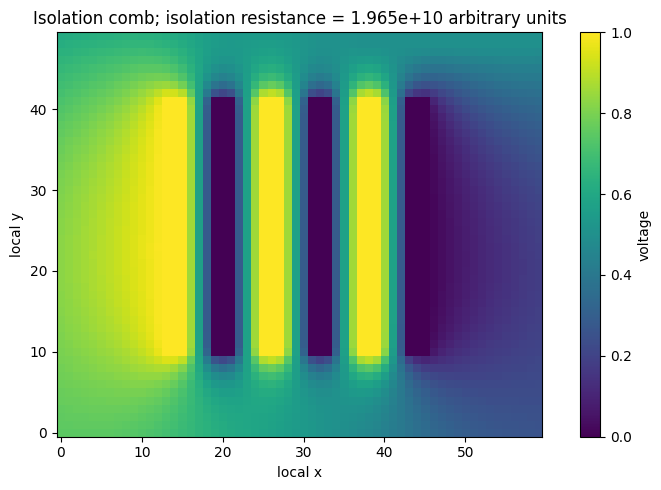

Comb leakage current: 5.088935445157267e-11
Comb isolation resistance: 19650475247.2665


In [ ]:
comb_A = np.zeros_like(sigma0, dtype=bool)
comb_B = np.zeros_like(sigma0, dtype=bool)

for k in range(6):
    x0 = 148 + 6*k
    if k % 2 == 0:
        comb_A[20:52, x0:x0+3] = True
    else:
        comb_B[20:52, x0:x0+3] = True

V_comb, I_leak = solve_resistor_network(cond, comb_A, comb_B)
R_iso = 1.0 / max(I_leak, 1e-30)

plt.figure(figsize=(8, 5))
plt.imshow(V_comb[10:60, 135:195], origin="lower", aspect="equal")
plt.colorbar(label="voltage")
plt.title(f"Isolation comb; isolation resistance = {R_iso:.3e} arbitrary units")
plt.xlabel("local x")
plt.ylabel("local y")
plt.tight_layout()
plt.show()

print("Comb leakage current:", I_leak)
print("Comb isolation resistance:", R_iso)

### v4 correction: net-aware compatibility

The earlier LCO gate could falsely fail at `state_compatibility` because it treated seed-to-seed adjacency as invalid even inside the same required route or pad. This v4 notebook assigns electrical net IDs before compatibility checking. Same-net conductive continuity is allowed; different-net conductive contact remains a short risk.

## 9. LCO non-compensatory pass/fail gate

The coupon does not pass by average score. It passes only if it survives the strict hierarchy:

\[
\text{state compatibility}
\succ
\text{electrical isolation}
\succ
\text{required connectivity}
\succ
\text{growth confinement}
\succ
\text{switching blur}
\succ
\text{repair}
\succ
\text{process burden}
\]

In [ ]:
def lco_gate(metrics, thresholds):
    tiers = [
        ("state_compatibility", metrics["bad_adjacent_pairs"] <= thresholds["bad_adjacent_pairs"]),
        ("electrical_isolation", metrics["R_iso"] >= thresholds["R_iso_min"]),
        ("required_connectivity", metrics["R_eff"] <= thresholds["R_eff_max"]),
        ("growth_confinement", metrics["stray_growth_fraction"] <= thresholds["stray_growth_fraction_max"]),
        ("switching_blur", metrics["leak_fraction"] <= thresholds["leak_fraction_max"]),
        ("repair_resolution", metrics["repair_region_conductive"] >= thresholds["repair_region_conductive_min"]),
        ("process_burden", metrics["process_score"] <= thresholds["process_score_max"]),
    ]

    for name, ok in tiers:
        if not ok:
            return "FAIL", name

    return "PASS", None

repair_region = np.zeros_like(sigma0, dtype=bool)
repair_region[66:75, 103:118] = True
repair_region_conductive = cond[repair_region].mean()

metrics = {
    "bad_adjacent_pairs": len(bad_pairs),
    "R_iso": R_iso,
    "R_eff": R_eff,
    "stray_growth_fraction": stray_fraction,
    "leak_fraction": leak_fraction,
    "repair_region_conductive": repair_region_conductive,
    "process_score": 1.0
}

thresholds = {
    "bad_adjacent_pairs": 300,
    "R_iso_min": 1e4,
    "R_eff_max": 1e4,
    "stray_growth_fraction_max": 0.005,
    "leak_fraction_max": 0.030,
    "repair_region_conductive_min": 0.05,
    "process_score_max": 5.0
}

status, failed_tier = lco_gate(metrics, thresholds)

print("=== CPS-1 DIGITAL COUPON LCO GATE ===")
for k, v in metrics.items():
    print(f"{k:28s}: {v}")
print("--------------------------------------")
print("RESULT:", status)
if failed_tier:
    print("First failed tier:", failed_tier)
else:
    print("All tiers passed.")

=== CPS-1 DIGITAL COUPON LCO GATE ===
bad_adjacent_pairs          : 0
R_iso                       : 19650475247.2665
R_eff                       : 16.91029778197993
stray_growth_fraction       : 0.0043506493506493505
leak_fraction               : 0.015163719138504641
repair_region_conductive    : 1.0
process_score               : 1.0
--------------------------------------
RESULT: PASS
All tiers passed.


## 10. Optional parameter sweep

This sweep re-runs the FEniCSx diffusion solver several times.  
It can take time in Colab. Reduce the grid size or number of candidates if needed.

In [ ]:
RUN_SWEEP = False  # Change to True when you want to sweep parameters.

if RUN_SWEEP:
    results = []

    for D_switch in [0.15, 0.25, 0.35, 0.50]:
        c_sw = run_fenicsx_diffusion(activation_mask, D_value=D_switch, source_strength=1.0,
                                     dt=0.03, nsteps=45, nx_cells=80, ny_cells=50)
        leak = ((c_sw[~activation_mask] > 0.25 * c_sw.max()).mean())

        for D_inhib in [0.10, 0.18, 0.30]:
            inh = run_fenicsx_diffusion(inhibitor_mask, D_value=D_inhib, source_strength=1.0,
                                        dt=0.04, nsteps=45, nx_cells=80, ny_cells=50)

            for growth_rate in [0.07, 0.10, 0.14]:
                h = simulate_plating_growth(sigma0, inh, growth_rate=growth_rate,
                                            steps=55, repair_to_seed=True)
                stray = ((h > 0.25 * h.max()) & (~valid_growth_region)).mean()
                cnd = build_conductivity_map(sigma0, h, metal_threshold=0.30)

                _, I_main = solve_resistor_network(cnd, left_pad, right_pad)
                R_main = 1.0 / max(I_main, 1e-30)

                _, I_c = solve_resistor_network(cnd, comb_A, comb_B)
                R_i = 1.0 / max(I_c, 1e-30)

                repair_cond = cnd[repair_region].mean()

                m = {
                    "bad_adjacent_pairs": len(bad_pairs),
                    "R_iso": R_i,
                    "R_eff": R_main,
                    "stray_growth_fraction": stray,
                    "leak_fraction": leak,
                    "repair_region_conductive": repair_cond,
                    "process_score": D_switch + D_inhib + growth_rate
                }

                st, tier = lco_gate(m, thresholds)
                results.append({
                    "D_switch": D_switch,
                    "D_inhib": D_inhib,
                    "growth_rate": growth_rate,
                    "status": st,
                    "failed_tier": tier,
                    **m
                })

    results_sorted = sorted(results, key=lambda r: (r["status"] != "PASS", r["R_eff"], r["stray_growth_fraction"]))

    print("Top candidates:")
    for r in results_sorted[:10]:
        print(r)

    print("PASS candidates:", sum(r["status"] == "PASS" for r in results), "/", len(results))
else:
    print("Parameter sweep skipped. Set RUN_SWEEP=True to run it.")

## 11. Next upgrades

1. Replace placeholder transition/coexistence/survival matrices with real materials data.
2. Add net IDs so seed-to-seed adjacency is judged by whether regions belong to the same electrical net.
3. Add etch-undercut PDE.
4. Replace the plating approximation with a Butler--Volmer or current-distribution electrodeposition model.
5. Add thermo-mechanical stress and delamination risk.
6. Add multilayer stack logic.
7. Export selected state maps as fabrication mask/CAD layers.